In [1]:
import torch

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from livelossplot import PlotLosses
from sklearn.metrics import roc_auc_score

In [186]:
## rewrite data... df --> signal/sideband --> data standardization/prep --> train

In [241]:
### create toy data dataset

def toy_data(background_fraction, signal_fraction, total_events=10000): 
    
    background_events = int(total_events * background_fraction)
    signal_events = int(total_events * signal_fraction)

    # background distribution
    mu_b = np.array([-1.0, -1.0, -1.0, -1.0, -1.0, -1.0])
    cov_b = 10 * np.eye(6)  # wider distribution
    Xb = np.random.multivariate_normal(mu_b, cov_b,size=background_events)
    Xb = np.array(Xb, dtype=np.float32)
    yb = np.zeros((len(Xb), 1), dtype=np.float32)

    # signal distribution
    mu_s = np.array([1.0, 1.0, 1.0, 1.0, 1.0, 1.0])
    cov_s = np.eye(6) # identity matrix for covariance
    Xs = np.random.multivariate_normal(mu_s, cov_s, size=signal_events)
    Xs = np.array(Xs, dtype=np.float32)
    ys = np.ones((len(Xs), 1), dtype=np.float32)

    X = np.vstack([Xb, Xs])
    y = np.concatenate([yb, ys])

    idx = np.random.permutation(len(X))
    X = X[idx]
    y = y[idx]
    
    df = pd.DataFrame(X, columns=['p1', 'p2', 'p3', 'p4', 'p5', 'p6'])
    df['true label'] = y

    return df

In [242]:
def plot_toy_data(df):

    df_signal = df[df['true label']==1]
    df_background = df[df['true label']==0]

    bins = [np.linspace(-15,15,100), np.linspace(-15,15,100)]

    # plot background data
    fig, axes = plt.subplots(1, 3, figsize=(15, 5), tight_layout=True)
    fig.suptitle('Background Data')
    color = 'Greys'
    
    h = axes[0].hist2d(df_background['p1'], df_background['p2'],
                       bins=bins, cmap=color)
    axes[0].set_title('p1 vs p2')
    axes[0].set_xlabel('p1', fontsize=10)
    axes[0].set_ylabel('p2', fontsize=10)
    c = fig.colorbar(h[3], ax=axes[0])
    c.ax.set_title('Counts', fontsize=8)
    
    h = axes[1].hist2d(df_background['p3'], df_background['p4'],
                       bins=bins, cmap=color)
    axes[1].set_title('p3 vs p4')
    axes[1].set_xlabel('p3', fontsize=10)
    axes[1].set_ylabel('p4', fontsize=10)
    c = fig.colorbar(h[3], ax=axes[1])
    c.ax.set_title('Counts', fontsize=8)
    
    h = axes[2].hist2d(df_background['p5'], df_background['p6'],
                       bins=bins, cmap=color)
    axes[2].set_title('p5 vs p6')
    axes[2].set_xlabel('p5', fontsize=10)
    axes[2].set_ylabel('p6', fontsize=10)
    c = fig.colorbar(h[3], ax=axes[2])
    c.ax.set_title('Counts', fontsize=8)

    plt.show()
    

    # plot signal data
    fig, axes = plt.subplots(1, 3, figsize=(15, 5), tight_layout=True)
    fig.suptitle('Signal Data')
    color = 'Reds'
    
    h = axes[0].hist2d(df_signal['p1'], df_signal['p2'],
                       bins=bins, cmap=color)
    axes[0].set_title('p1 vs p2')
    axes[0].set_xlabel('p1', fontsize=10)
    axes[0].set_ylabel('p2', fontsize=10)
    c = fig.colorbar(h[3], ax=axes[0])
    c.ax.set_title('Counts', fontsize=8)
    
    h = axes[1].hist2d(df_signal['p3'], df_signal['p4'],
                       bins=bins, cmap=color)
    axes[1].set_title('p3 vs p4')
    axes[1].set_xlabel('p3', fontsize=10)
    axes[1].set_ylabel('p4', fontsize=10)
    c = fig.colorbar(h[3], ax=axes[1])
    c.ax.set_title('Counts', fontsize=8)
    
    h = axes[2].hist2d(df_signal['p5'], df_signal['p6'],
                       bins=bins, cmap=color)
    axes[2].set_title('p5 vs p6')
    axes[2].set_xlabel('p5', fontsize=10)
    axes[2].set_ylabel('p6', fontsize=10)
    c = fig.colorbar(h[3], ax=axes[2])
    c.ax.set_title('Counts', fontsize=8)
    
    plt.show()

In [243]:
def toy_signal_sideband(df, sig_factor=1.5):

    df_signal = df[df['true label']==1]
    
    signal_parameter = df_signal['p6']

    sp_median = np.median(signal_parameter)
    sp_std = np.std(signal_parameter)
    print('Signal Parameter p6 median = ', sp_median)
    print('Signal Parameter p6 standard deviation = ', sp_std)
    
    sig_min = sp_median - sig_factor * sp_std
    sig_max = sp_median + sig_factor * sp_std
    
    print('Signal Region Range: ', sig_min, ' to ', sig_max)

    plt.hist(signal_parameter, bins=30, color='red', edgecolor='black')
    plt.xlabel('Values')
    plt.ylabel('Frequency')
    plt.title('Signal Parameter Histogram')
    plt.show()


    # background region is 0, signal region is 1
    df['region label'] = np.where((df['p6'] >= sig_min) & (df['p6'] <= sig_max), 1, 0)

    # creates two data frames, one of signal region events, one of sideband region events
    df_sig_region = df[df['region label']==1]
    df_sb_region = df[df['region label']==0]
    
    # creates two data frames from signal region, one which has true signal events, one which has true background events
    df_sig_region_stream = df_sig_region[df_sig_region['true label']==1]
    df_sig_region_background = df_sig_region[df_sig_region['true label']==0]

    # creates two data frames from background region, one which has true signal events, one which has true background events
    df_sb_region_stream = df_sb_region[df_sb_region['true label']==1]
    df_sb_region_background = df_sb_region[df_sb_region['true label']==0]
    
    print(f'Signal Region has {len(df_sig_region)} events, {len(df_sig_region_stream)} stream and {len(df_sig_region_background)} background.')
    print(f'Sideband Region has {len(df_sb_region)} events, {len(df_sb_region_stream)} stream and {len(df_sb_region_background)} background.')          

    sbfiller_low = sp_median - 3 * sp_std
    sbfiller_high = sp_median + 3 * sp_std
    bins = np.linspace(sbfiller_low - (sig_min - sbfiller_low), sbfiller_high + (sbfiller_high - sig_max), 50)

    plt.hist(df_sig_region_stream['p6'], label='Signal Region', color='red', alpha=1, edgecolor='white', bins=bins)
    plt.hist(df_sb_region_stream['p6'], label='Sideband Region', color='red', alpha=0.5, edgecolor='white', bins=bins)
    plt.xlabel('p6')
    plt.ylabel('Number of Events')
    plt.title('Signal Events in Toy Dataset')
    plt.legend()
    plt.show()
    
    plt.hist(df_sig_region_background['p6'], label='Signal Region', color='grey', alpha=1, bins=bins)
    plt.hist(df_sb_region_background['p6'], label='Sideband Region', color='grey', alpha=0.5, bins=bins)
    plt.xlabel('p6')
    plt.ylabel('Number of Events')
    plt.title('Background Events in Toy Dataset')
    plt.legend()
    plt.show()

    return df

In [244]:
class NeuralNetwork(nn.Module): # class groups variables and functions together
    def __init__(self, input_dim = 5, hidden_dim = 256, output_dim = 1): # create tool, parameters for recalling, call function is used after
        super().__init__() # access all methods, attributes, etc of class
        self.NeuralNetwork = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(p=0.2),       
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(p=0.2),       
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(p=0.2),       
            nn.Linear(hidden_dim, output_dim),
            nn.Sigmoid()
        )
    def forward(self, x):
        return self.NeuralNetwork(x)

In [245]:
def train(df, batch_size=16, learning_rate=0.0001, epochs=20):
    # split into 80/10/10 groups, equal percentage of signal/sideband region

    # split indices of signal region
    df_sig_region = df[df['region label']==1]
    sig_reg_len = len(df_sig_region)

    sig_indices = np.random.permutation(sig_reg_len)
    train_len = int(0.8 * sig_reg_len)
    train_index = sig_indices[:train_len]
    valtest_indices = sig_indices[train_len:]
    val_len = int(0.1 * sig_reg_len)
    val_index = valtest_indices[:val_len]
    test_index = valtest_indices[val_len:]

    df_sigtrain = df_sig_region.iloc[train_index]
    df_sigval = df_sig_region.iloc[val_index]
    df_sigtest = df_sig_region.iloc[test_index]


    # split indices of sideband region
    df_sb_region = df[df['region label']==0]
    sb_reg_len = len(df_sb_region)

    sb_indices = np.random.permutation(sb_reg_len)
    train_len = int(0.8 * sb_reg_len)
    train_index = sb_indices[:train_len]
    valtest_indices = sb_indices[train_len:]
    val_len = int(0.1 * sb_reg_len)
    val_index = valtest_indices[:val_len]
    test_index = valtest_indices[val_len:]

    df_sbtrain = df_sb_region.iloc[train_index]
    df_sbval = df_sb_region.iloc[val_index]
    df_sbtest = df_sb_region.iloc[test_index]

    # shuffle data frames
    df_train = pd.concat([df_sigtrain, df_sbtrain]).sample(frac=1).reset_index(drop=True)
    df_val   = pd.concat([df_sigval, df_sbval]).sample(frac=1).reset_index(drop=True)
    df_test  = pd.concat([df_sigtest, df_sbtest]).sample(frac=1).reset_index(drop=True)    

    # print(f"Training set has {len(df_train)} events, {len(df_train[df_train['region label']==1])/len(df_train)} from the signal region and {len(df_train[df_train['region label']==0])/len(df_train)} from the sideband region.")
    # print(f"Validation set has {len(X_val)} events, {len(df_val[df_val['region label']==1])/len(df_val)} from the signal region and {len(df_val[df_val['region label']==0])/len(df_val)} from the sideband region.")
    # print(f"Test set has {len(X_test)} events, {len(df_test[df_test['region label']==1])/len(df_test)} from the signal region and {len(df_test[df_test['region label']==0])/len(df_test)} from the sideband region.")

    scaler = StandardScaler()

    X_train = scaler.fit_transform(df_train[['p1', 'p2', 'p3', 'p4', 'p5']])
    y_train = df_train['region label']

    X_val = scaler.transform(df_val[['p1', 'p2', 'p3', 'p4', 'p5']])
    y_val = df_val['region label']

    X_test = scaler.transform(df_test[['p1', 'p2', 'p3', 'p4', 'p5']])
    y_test = df_test['region label']
    y_test_true = df_test['true label']

    X_train_tensor = torch.tensor(np.array(X_train))
    y_train_tensor = torch.tensor(y_train)

    X_val_tensor = torch.tensor(np.array(X_val))
    y_val_tensor = torch.tensor(y_val)

    X_test_tensor = torch.tensor(np.array(X_test))
    y_test_tensor = torch.tensor(y_test)
    y_test_true_tensor = torch.tensor(y_test_true)

    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
    val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
    test_dataset = TensorDataset(X_test_tensor, y_test_tensor, y_test_true_tensor)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu') # requires previous check for gpu
    print(f'Using device: {device}')

    

    class NeuralNetwork(nn.Module): # class groups variables and functions together
        def __init__(self, input_dim = 5, hidden_dim = 256, output_dim = 1): # create tool, parameters for recalling, call function is used after
            super().__init__() # access all methods, attributes, etc of class
            self.NeuralNetwork = nn.Sequential(
                nn.Linear(input_dim, hidden_dim),
                nn.ReLU(),
                nn.Dropout(p=0.2),       
                nn.Linear(hidden_dim, hidden_dim),
                nn.ReLU(),
                nn.Dropout(p=0.2),       
                nn.Linear(hidden_dim, hidden_dim),
                nn.ReLU(),
                nn.Dropout(p=0.2),       
                nn.Linear(hidden_dim, output_dim),
                nn.Sigmoid()
            )
        def forward(self, x):
            return self.NeuralNetwork(x)

    
    # initialize model, loss function, optimizer
    model = NeuralNetwork(input_dim = 5, hidden_dim = 256, output_dim = 1).to(device)
    loss_fn = nn.BCELoss() # common loss function for multi-class classification problems
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    liveloss = PlotLosses(figsize=(9,4))

    logs = {}

    for epoch in range(epochs):  # loop over the dataset multiple times (overfitting at 50 epochs)

        # training
        model.train()
        total_train_loss = 0
        train_acc, count = 0.0, 0
        for inputs, region_labels in train_loader:
            optimizer.zero_grad()  # zero the parameter gradients, updates weights only on the mini batch
            inputs = inputs.to(device).float()
            region_labels = region_labels.to(device).float()
            
            out = model(inputs).squeeze(1)  # forward pass
            loss = loss_fn(out, region_labels)  # compute loss
            loss.backward()  # backward pass
            optimizer.step()  # update parameters
            total_train_loss += loss.item()

            predictions = (out > 0.5).float()
            train_acc += (predictions == region_labels).sum().item()
            count += region_labels.size(0)

        train_loss_per_batch = total_train_loss / len(train_loader)
        logs['loss'] = train_loss_per_batch

        train_count_accuracy = train_acc / count
        logs['acc per count'] = train_count_accuracy


        # validation
        model.eval()
        total_val_loss = 0
        val_acc, count = 0.0, 0
        for inputs, region_labels in val_loader:
            inputs = inputs.to(device).float()
            region_labels = region_labels.to(device).float()

            out = model(inputs).squeeze(1)  # forward pass
            loss = loss_fn(out, region_labels)  # compute loss
            total_val_loss += loss.item()

            predictions = (out > 0.5).float()
            val_acc += (predictions == region_labels).sum().item()
            count += region_labels.size(0)

        val_loss_per_batch = total_val_loss / len(val_loader)
        logs['val_loss'] = val_loss_per_batch

        val_count_accuracy = val_acc / count
        logs['val_acc per count'] = val_count_accuracy

        liveloss.update(logs)
        liveloss.send()
        print(f'Epoch {epoch}, Loss: {loss.item()}')
        print(f'Epoch {epoch}, Accuracy: {val_count_accuracy}')

    
    # run on test set
    model.eval()
    test_loss, test_acc, count = 0.0, 0.0, 0
    all_scores = []
    all_region_labels = []
    all_true_labels = []
    raw_scores = []

    with torch.no_grad():
        for inputs, region_labels, true_labels in test_loader:
            
            inputs = inputs.to(device).float()
            region_labels = region_labels.to(device).float()
        
            out = model(inputs).squeeze(1)
            raw_scores.extend(out.squeeze().cpu().numpy())
            loss = loss_fn(out, region_labels)
            test_loss += loss.item() * inputs.size(0)

            scores = (out > 0.5).float()
            all_scores.extend(scores.squeeze().cpu().numpy())
            
            all_region_labels.extend(region_labels.squeeze().cpu().numpy())
            all_true_labels.extend(true_labels.numpy())
                
            # Track counts
            test_acc += (scores == region_labels).sum().item()
            count += region_labels.size(0)

    all_scores = np.array(all_scores)
    all_region_labels = np.array(all_region_labels)
    all_true_labels = np.array(all_true_labels)
    raw_scores = np.array(raw_scores)

    print(' ')
    print('----------------------------------------')
    print(' ')

    print(f"Average test loss: {test_loss/count:.4f} | Test accuracy: {test_acc/count:.3f}")

    plt.hist(raw_scores)
    plt.title('Raw NN Scores')

    # calculate ROC-AUC score
    auc_regions = roc_auc_score(all_region_labels, raw_scores)
    print(' ')
    print(f"Test ROC-AUC for fully supervised signal/sb region classifier: {auc_regions:.3f}  (0.5 = no separation, 1.0 = perfect)")

    auc_true = roc_auc_score(all_true_labels, raw_scores)
    print(f"Test ROC-AUC for true background/stream labels: {auc_true:.3f}  (0.5 = no separation, 1.0 = perfect)")

    # calculate purity and completeness

    true_pos = np.sum((all_scores == 1) & (all_true_labels == 1))
    false_pos = np.sum((all_scores == 1) & (all_true_labels == 0))
    true_neg = np.sum((all_scores == 0) & (all_true_labels == 0))
    false_neg = np.sum((all_scores == 0) & (all_true_labels == 1))

    purity = true_pos / (true_pos + false_pos)
    completeness = true_pos / (true_pos + false_neg)
    print(' ')
    print(f'Purity = {purity}')
    print(f'Completeness = {completeness}')


In [246]:
def maketoydata(background_fraction, signal_fraction):
    df = toy_data(background_fraction, signal_fraction)
    plot_toy_data(df)
    df = toy_signal_sideband(df)
    return df

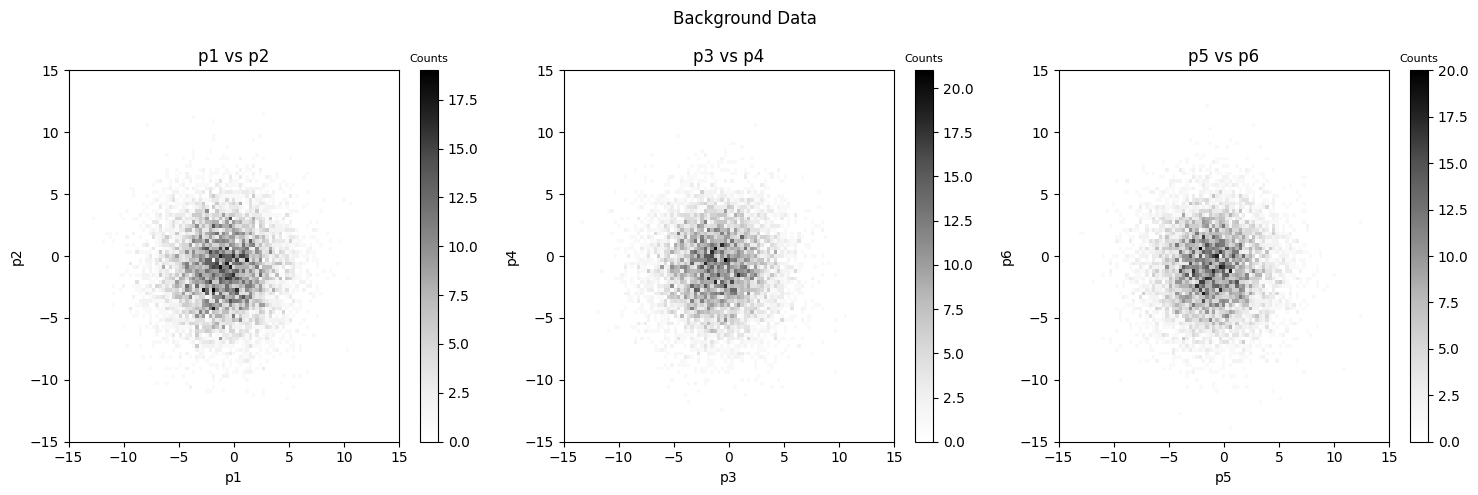

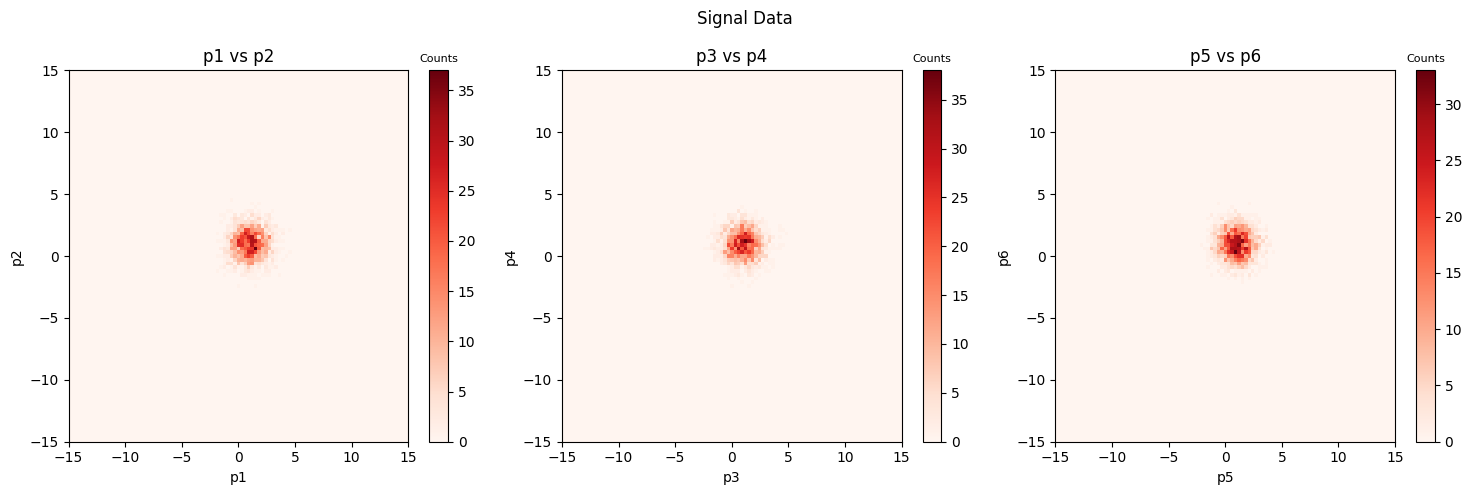

Signal Parameter p6 median =  0.9584533
Signal Parameter p6 standard deviation =  0.9814772
Signal Region Range:  -0.5137625  to  2.430669


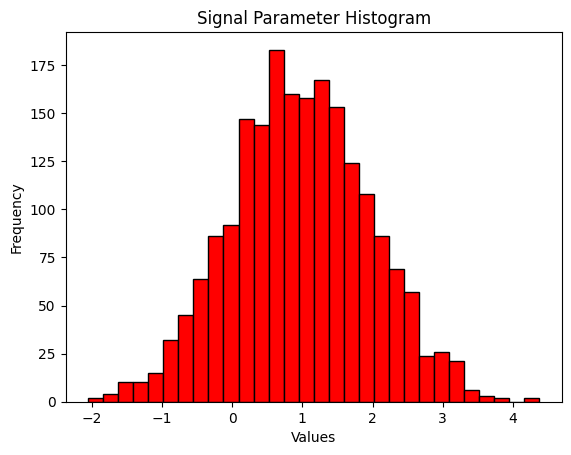

Signal Region has 4130 events, 1728 stream and 2402 background.
Sideband Region has 5870 events, 272 stream and 5598 background.


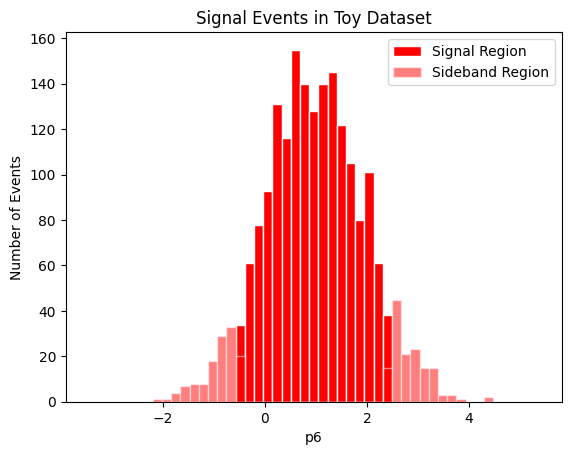

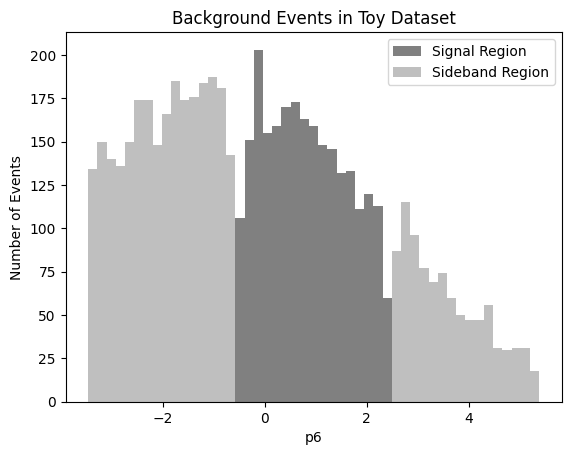

In [247]:
df = maketoydata(0.8, 0.2)

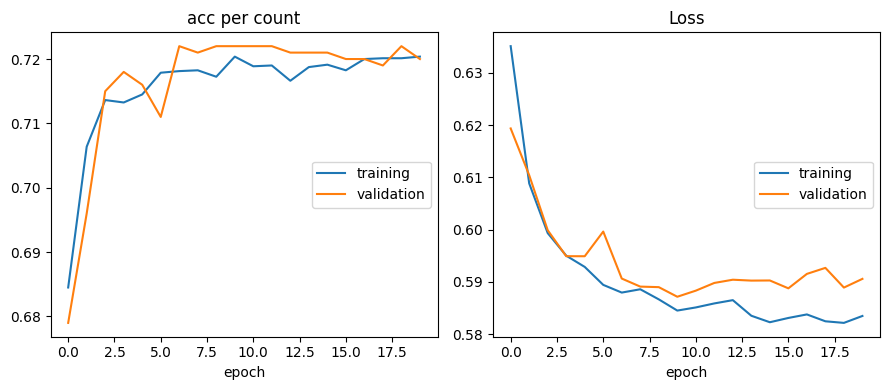

acc per count
	training         	 (min:    0.684, max:    0.720, cur:    0.720)
	validation       	 (min:    0.679, max:    0.722, cur:    0.720)
Loss
	training         	 (min:    0.582, max:    0.635, cur:    0.583)
	validation       	 (min:    0.587, max:    0.619, cur:    0.591)
Epoch 19, Loss: 0.6006595492362976
Epoch 19, Accuracy: 0.72
 
----------------------------------------
 
Average test loss: 0.5969 | Test accuracy: 0.706
 
Test ROC-AUC for fully supervised signal/sb region classifier: 0.660  (0.5 = no separation, 1.0 = perfect)
Test ROC-AUC for true background/stream labels: 0.988  (0.5 = no separation, 1.0 = perfect)
 
Purity = 0.8731707317073171
Completeness = 0.9728260869565217


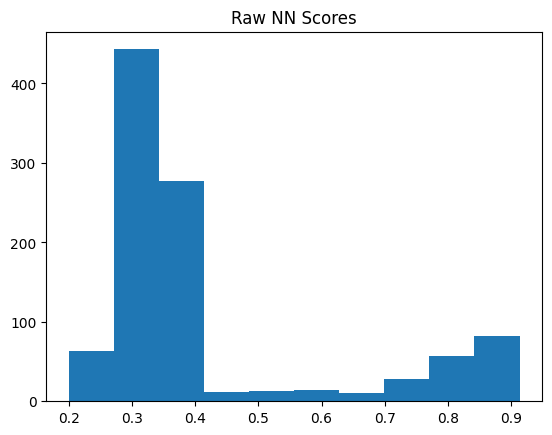

In [248]:
train(df)